### N_HVG selection justification (breast = 100, lung = 600)

This notebook documents the evidence behind fixing `N_HVG` at a different, cohort-specific value for breast vs. lung, applied identically across all three models (ElasticNet, RandomForest, LassoedForest) rather than tuned per model or shared across cohorts.

Evidence 1 re-analyzes a `n_hvg x max_depth x min_samples_leaf` grid search for LassoedForest, saved as `growth_lassoedforest_sensitivity_summary_{breast,lung}.csv` under `results/1_doublingRate/`.

In [1]:
import sys
from pathlib import Path

PARENT_DIR = Path.cwd().parent
if str(PARENT_DIR) not in sys.path:
    sys.path.insert(0, str(PARENT_DIR))

from pipeline_utils import make_case1_paths, compare_hvg_across_models
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

paths = make_case1_paths()
PROC_DIR = paths["proc"]
RESULTS_DIR = paths["results"]
FIGURES_DIR = paths["figures"]
FIGURES_SUPP_DIR = paths["figures_supp"]

RANDOM_STATE = 42

### Evidence 1: LassoedForest's own hyperparameter grid shows complete separation by N_HVG for lung

A full grid search (`n_hvg x max_depth x min_samples_leaf`) was previously run for LassoedForest and saved as `growth_lassoedforest_sensitivity_summary_{breast,lung}.csv`. This section re-analyzes those existing results rather than re-running the grid search.

In [2]:
breast_grid = pd.read_csv(PROC_DIR / "growth_lassoedforest_sensitivity_summary_breast.csv")
lung_grid = pd.read_csv(PROC_DIR / "growth_lassoedforest_sensitivity_summary_lung.csv")

print("Breast: mean_AUROC by n_hvg (averaged across max_depth/min_samples_leaf)")
display(breast_grid.groupby("n_hvg")["mean_AUROC"].agg(["mean", "std", "min", "max"]).round(3))

print("\nLung: mean_AUROC by n_hvg (averaged across max_depth/min_samples_leaf)")
display(lung_grid.groupby("n_hvg")["mean_AUROC"].agg(["mean", "std", "min", "max"]).round(3))

# Complete-separation check: does every n_hvg=600 combo beat every n_hvg=100 combo for lung?
lung_600 = lung_grid.loc[lung_grid["n_hvg"] == 600, "mean_AUROC"]
lung_100 = lung_grid.loc[lung_grid["n_hvg"] == 100, "mean_AUROC"]
print(
    f"\nLung: min(n_hvg=600 AUROC)={lung_600.min():.3f} vs "
    f"max(n_hvg=100 AUROC)={lung_100.max():.3f} -- "
    f"complete separation: {lung_600.min() > lung_100.max()}"
)

# For reference: breast shows the opposite preference (fewer genes).
breast_100 = breast_grid.loc[breast_grid["n_hvg"] == 100, "mean_AUROC"]
breast_600 = breast_grid.loc[breast_grid["n_hvg"] == 600, "mean_AUROC"]
print(
    f"Breast: min(n_hvg=100 AUROC)={breast_100.min():.3f} vs "
    f"max(n_hvg=600 AUROC)={breast_600.max():.3f} -- "
    f"complete separation: {breast_100.min() > breast_600.max()}"
)

Breast: mean_AUROC by n_hvg (averaged across max_depth/min_samples_leaf)


,mean,std,min,max
n_hvg,,,,
100,0.708,0.010,0.686,0.716
300,0.685,0.016,0.658,0.714
600,0.643,0.019,0.620,0.668



Lung: mean_AUROC by n_hvg (averaged across max_depth/min_samples_leaf)


,mean,std,min,max
n_hvg,,,,
100,0.582,0.019,0.560,0.603
300,0.626,0.036,0.579,0.655
600,0.759,0.041,0.705,0.789



Lung: min(n_hvg=600 AUROC)=0.705 vs max(n_hvg=100 AUROC)=0.603 -- complete separation: True
Breast: min(n_hvg=100 AUROC)=0.686 vs max(n_hvg=600 AUROC)=0.668 -- complete separation: True


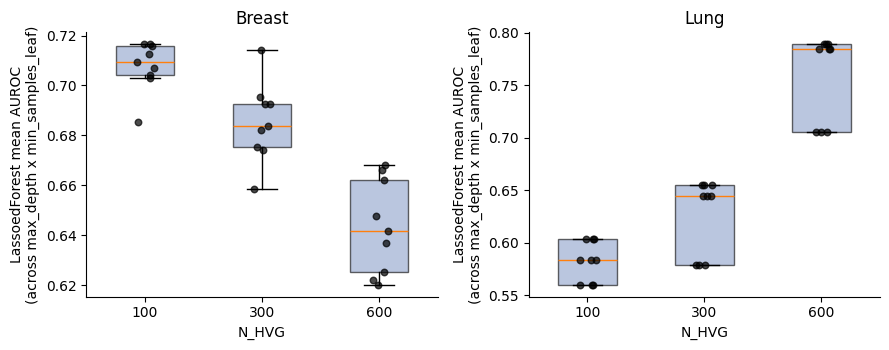

Saved figure to: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/figures_tables/figures_supp/supp_figure1d_hvg_lassoedforest_grid.png


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))
for ax, (cohort_label, grid_df) in zip(axes, [("Breast", breast_grid), ("Lung", lung_grid)]):
    n_hvg_values = sorted(grid_df["n_hvg"].unique())
    positions = np.arange(len(n_hvg_values))
    data = [grid_df.loc[grid_df["n_hvg"] == n, "mean_AUROC"].to_numpy() for n in n_hvg_values]

    box = ax.boxplot(data, positions=positions, widths=0.5, patch_artist=True, showfliers=False)
    for patch in box["boxes"]:
        patch.set_facecolor("#8da0cb")
        patch.set_alpha(0.6)

    rng = np.random.default_rng(RANDOM_STATE)
    for pos, values in zip(positions, data):
        jitter = rng.uniform(-0.08, 0.08, size=len(values))
        ax.scatter(pos + jitter, values, s=22, color="black", alpha=0.7, zorder=3)

    ax.set_xticks(positions)
    ax.set_xticklabels(n_hvg_values)
    ax.set_xlabel("N_HVG")
    ax.set_ylabel("LassoedForest mean AUROC\n(across max_depth x min_samples_leaf)")
    ax.set_title(cohort_label)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
out_figure_evidence1 = FIGURES_SUPP_DIR / "supp_figure1d_hvg_lassoedforest_grid.png"
plt.savefig(out_figure_evidence1, dpi=300, bbox_inches="tight")
plt.savefig(out_figure_evidence1.with_suffix(".pdf"), bbox_inches="tight")
plt.show()
print(f"Saved figure to: {out_figure_evidence1}")

### Evidence 2: The N_HVG preference generalizes to ElasticNet and RandomForest, not just LassoedForest

Evidence 1 only tested LassoedForest. This section checks whether ElasticNet and RandomForest -- fit with the same fixed `max_depth`/`min_samples_leaf` used before the nested-search redesign -- show the same monotonic N_HVG pattern already seen for LassoedForest (breast: 100 > 300 > 600; lung: 100 < 300 < 600), to rule out the pattern being an artifact specific to LassoedForest's tree-probability architecture.

**This cell is compute-heavy (repeated CV at three N_HVG values, for both cohorts).**

In [4]:
n_hvg_grid = [100, 300, 600]

breast_df = pd.read_csv(PROC_DIR / "rna_doubling_time_merged_breast.csv", index_col=0)
lung_df = pd.read_csv(PROC_DIR / "rna_doubling_time_merged_lung.csv", index_col=0)

# Fixed at the pre-nested-search production defaults, so this isolates N_HVG's own effect
# rather than conflating it with the max_depth/min_samples_leaf search.
breast_rf_params = dict(
    n_estimators=500, max_depth=3, min_samples_leaf=1,
    max_features="sqrt", random_state=RANDOM_STATE, n_jobs=-1,
)
lung_rf_params = dict(
    n_estimators=500, max_depth=3, min_samples_leaf=2,
    max_features="sqrt", random_state=RANDOM_STATE, n_jobs=-1,
)

breast_comparison = compare_hvg_across_models(
    breast_df, n_hvg_grid=n_hvg_grid, n_splits=5, n_repeats=10, rf_params=breast_rf_params,
)
breast_comparison["Cohort"] = "Breast"

lung_comparison = compare_hvg_across_models(
    lung_df, n_hvg_grid=n_hvg_grid, n_splits=3, n_repeats=10, rf_params=lung_rf_params,
)
lung_comparison["Cohort"] = "Lung"

hvg_comparison_df = pd.concat([breast_comparison, lung_comparison], ignore_index=True)

out_table_evidence2 = PROC_DIR / "hvg_generalization_check.csv"
hvg_comparison_df.to_csv(out_table_evidence2, index=False)
print(f"Saved: {out_table_evidence2}")
display(hvg_comparison_df)

/Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/1_doublingRate/pipeline_utils.py:121: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r = spearmanr(a, b).correlation


/Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/1_doublingRate/pipeline_utils.py:121: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r = spearmanr(a, b).correlation


/Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/1_doublingRate/pipeline_utils.py:121: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r = spearmanr(a, b).correlation


/Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/1_doublingRate/pipeline_utils.py:121: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r = spearmanr(a, b).correlation


/Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/1_doublingRate/pipeline_utils.py:121: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r = spearmanr(a, b).correlation


...

/Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/1_doublingRate/pipeline_utils.py:121: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r = spearmanr(a, b).correlation


/Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/1_doublingRate/pipeline_utils.py:121: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r = spearmanr(a, b).correlation


/Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/1_doublingRate/pipeline_utils.py:121: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r = spearmanr(a, b).correlation


Saved: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/1_doublingRate/hvg_generalization_check.csv


,n_hvg,Model,n_completed_folds,mean_AUROC,sd_AUROC,mean_Spearman,sd_Spearman,Cohort
0,100,ElasticNet,50,0.774933,0.172884,0.432381,0.259735,Breast
1,100,RandomForest,50,0.705758,0.180090,0.317675,0.273347,Breast
2,300,ElasticNet,50,0.748333,0.153069,0.365754,0.253221,Breast
3,300,RandomForest,50,0.705672,0.161787,0.332917,0.267012,Breast
4,600,ElasticNet,50,0.717463,0.194147,0.353461,0.250573,Breast
5,600,RandomForest,50,0.700174,0.167282,0.340626,0.244992,Breast
6,100,ElasticNet,30,0.618704,0.217509,0.180476,0.378359,Lung
7,100,RandomForest,30,0.657963,0.240330,0.222540,0.358651,Lung
8,300,ElasticNet,30,0.662500,0.242458,0.283651,0.428632,Lung
9,300,RandomForest,30,0.668889,0.254532,0.268095,0.438919,Lung


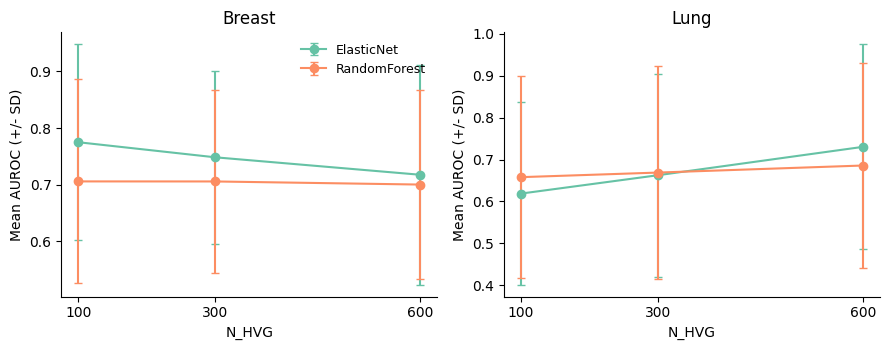

Saved figure to: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/figures_tables/figures_supp/supp_figure1c_hvg_generalization.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.6), sharey=False)
model_colors = {"ElasticNet": "#66c2a5", "RandomForest": "#fc8d62"}

for ax, cohort_label in zip(axes, ["Breast", "Lung"]):
    sub = hvg_comparison_df[hvg_comparison_df["Cohort"] == cohort_label]
    for model_name, color in model_colors.items():
        model_sub = sub[sub["Model"] == model_name].sort_values("n_hvg")
        ax.errorbar(
            model_sub["n_hvg"], model_sub["mean_AUROC"], yerr=model_sub["sd_AUROC"],
            marker="o", color=color, label=model_name, capsize=3, linewidth=1.5,
        )
    ax.set_xticks(n_hvg_grid)
    ax.set_xlabel("N_HVG")
    ax.set_ylabel("Mean AUROC (+/- SD)")
    ax.set_title(cohort_label)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].legend(fontsize=9, frameon=False)
plt.tight_layout()
out_figure_evidence2 = FIGURES_SUPP_DIR / "supp_figure1c_hvg_generalization.png"
plt.savefig(out_figure_evidence2, dpi=300, bbox_inches="tight")
plt.savefig(out_figure_evidence2.with_suffix(".pdf"), bbox_inches="tight")
plt.show()
print(f"Saved figure to: {out_figure_evidence2}")

### Decision

- `N_HVG` is fixed per cohort -- 100 for breast, 600 for lung -- not nested-tuned within CV, and applied identically across ElasticNet, RandomForest, and LassoedForest.
- **Evidence 1** shows this is a robust main effect for LassoedForest: every `n_hvg=600` combination beats every `n_hvg=100` combination for lung, regardless of `max_depth`/`min_samples_leaf` (complete separation, not a single noisy winner).
- **Evidence 2** shows the same direction of preference generalizes to ElasticNet and RandomForest, so the pattern is not specific to LassoedForest's tree-probability architecture -- consistent with the likely mechanism: HVG selection by variance is itself unreliable at lung's small per-fold sample size (~12 training-extreme samples), and a wider gene pool partly compensates for that unreliable ranking.
- `N_HVG` is kept fixed rather than folded into the per-fold nested `max_depth`/`min_samples_leaf` search because (a) lung's inner-CV folds are already down to ~3-4 samples, and adding another search dimension would spread that already-thin signal further, and (b) keeping `N_HVG` shared across models within a cohort preserves a single, consistent feature representation for the ElasticNet/RandomForest/LassoedForest performance comparison in `4-ml_model_interpretation.ipynb`.